# Opening a FITS image from S3

A DSA-2000 continuum image is about 2 GB. You can see a single radio source in it in roughly a
second, and you do not need to download the file to do it. The habit worth building is that
**the image stays in the bucket and you reach into it**, pulling only the pixels you are going
to look at. This notebook opens one such image straight from S3 and **displays a cutout of it
without ever transferring the whole file.**

Browse the [notebooks index](README.md).

**At a glance** · Starter · Packages: `astropy`, `s3fs`, `matplotlib`

- **Question:** how do I open, inspect and view a FITS image that lives in an S3 bucket, and how
  do I avoid pulling two gigabytes to look at a few arcminutes of sky?
- **Prerequisite:** run this on the symposium JupyterHub, where credentials and the data are
  already in place. Off the hub you need AWS credentials for the bucket; the bucket is private,
  so unauthenticated access will not work.
- **Takeaway:** `hdu.section` instead of `hdu.data`, and why that one change is the difference
  between 2 MB and 2.2 GB.

## Parameters
Change these inputs first; leave the calculation cells intact.

In [1]:
BUCKET = "schmidt-observatory-system"
KEY = "dsa/v2-convening/mockfm_DPR-DSA-03_mp37_701.235_20260922.fits"
MOUNT = "~/s3"      # the bucket is also NFS-mounted here on the hub
CUTOUT = 512        # cutout size in pixels, per side

## 1. Two routes to the same bytes

On this hub the bucket can be reached two ways, and it is worth being deliberate about which
one you use.

**The S3 API** (`s3fs`, which astropy drives for you when you pass `use_fsspec=True`) talks to
S3 over HTTP. It works here, it works on your laptop with credentials, and the same code works
against any other S3 archive. It is the portable option.

**The NFS mount** at `~/s3` makes the bucket look like an ordinary directory, so `fits.open`
takes a plain path. It is convenient and it is fast, but it exists only inside this hub — that
path is meaningless anywhere else.

Use the mount when you are working here and want the shortest path to the data. Use the API
when you are writing something that has to run somewhere else too. Both are shown below so you
can see they return identical pixels.

In [2]:
import os, time
from astropy.io import fits

s3_url = f"s3://{BUCKET}/{KEY}"
mount_path = os.path.expanduser(f"{MOUNT}/{BUCKET}/{KEY}")

t0 = time.perf_counter()
hdul = fits.open(s3_url, use_fsspec=True)
print(f"opened over the S3 API in {time.perf_counter() - t0:.2f} s")

hdu = hdul[0]
hdr = hdu.header
print(f"file is {hdr['NAXIS1'] * hdr['NAXIS2'] * abs(hdr['BITPIX']) / 8 / 1024**3:.2f} GiB of pixels")

opened over the S3 API in 1.09 s
file is 2.21 GiB of pixels


In [3]:
# The same file through the mount, for comparison. Only available on the hub.
if os.path.exists(mount_path):
    t0 = time.perf_counter()
    with fits.open(mount_path) as local:
        probe_mount = local[0].section[0, 0, 8360:8364, 8361:8365]
    t_mount = time.perf_counter() - t0

    t0 = time.perf_counter()
    probe_s3 = hdu.section[0, 0, 8360:8364, 8361:8365]
    t_s3 = time.perf_counter() - t0

    import numpy as np
    print(f"mount  {t_mount:5.2f} s")
    print(f"S3 API {t_s3:5.2f} s")
    print(f"identical pixels: {np.array_equal(probe_mount, probe_s3)}")
else:
    print(f"No mount at {mount_path} -- continuing with the S3 API alone.")

mount   0.00 s
S3 API  1.10 s
identical pixels: True


## 2. What the file contains

`hdul.info()` reads only the header blocks, a few kilobytes, so this costs nothing even though
the file is two gigabytes. Reading headers first and deciding what you want is the whole
technique: survey a hundred files cheaply, then fetch pixels from the two you care about.

In [4]:
hdul.info()

Filename: <class 's3fs.core.S3File'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      41   (17232, 17232, 1, 1)   float64   


In [5]:
for card in ("TELESCOP", "OBJECT", "BTYPE", "BUNIT", "CRVAL3", "BMAJ", "BMIN", "BPA"):
    if card in hdr:
        print(f"{card:<9}= {hdr[card]}")

pix_arcsec = abs(hdr["CDELT1"]) * 3600
print(f"\npixel scale {pix_arcsec:.3f} arcsec")
print(f"field       {hdr['NAXIS1'] * pix_arcsec / 3600:.2f} deg across")
print(f"frequency   {hdr['CRVAL3'] / 1e6:.3f} MHz")
print(f"beam        {hdr['BMAJ'] * 3600:.2f} x {hdr['BMIN'] * 3600:.2f} arcsec at {hdr['BPA']:.1f} deg")

TELESCOP = DSA2000
OBJECT   = constructed_sky_model
BTYPE    = Intensity
BUNIT    = JY/BEAM
CRVAL3   = 701235000.0
BMAJ     = 0.0015946906
BMIN     = 0.001243894
BPA      = 88.92056

pixel scale 1.831 arcsec
field       8.76 deg across
frequency   701.235 MHz
beam        5.74 x 4.48 arcsec at 88.9 deg


## 3. Three things that will trip you up

This file is a radio image, and radio images have conventions that surprise people coming from
optical data.

**The array is four-dimensional.** `NAXIS3` and `NAXIS4` are the frequency and Stokes axes, both
of length 1. They are degenerate — they carry no extra data — but they are still there, so the
shape is `(1, 1, 17232, 17232)` and `imshow(hdu.data)` would fail. Index `[0, 0]` to get the sky
plane.

**The WCS has four axes too.** Matplotlib wants a two-axis WCS to plot against, so take
`wcs.celestial`, which drops frequency and Stokes and keeps the sky.

**`.data` would read the whole thing.** It is the attribute everyone reaches for, and here it
means two gigabytes over the network into memory. `.section` takes the same slice syntax but
converts it into byte ranges and fetches only what the slice covers. On a remote file, prefer
`.section` every time.

In [6]:
from astropy.wcs import WCS

wcs = WCS(hdr)
print(f"data shape      {hdu.shape}")
print(f"WCS axes        {wcs.naxis}  {wcs.axis_type_names}")
print(f"celestial axes  {wcs.celestial.naxis}  {wcs.celestial.axis_type_names}")

data shape      (1, 1, 17232, 17232)


WCS axes        4  ['RA', 'DEC', 'FREQ', 'STOKES']
celestial axes  2  ['RA', 'DEC']


## 4. A cutout, and only a cutout

`CRPIX1`/`CRPIX2` give the reference pixel, which for this image is the field centre. Taking a
512-pixel box around it costs a couple of megabytes.

Slicing the WCS alongside the data keeps the coordinates honest: `wcs.celestial[y0:y1, x0:x1]`
returns a WCS whose origin matches the cutout, so the axes in the next plot show the true sky
position rather than offsets from an origin that is no longer there.

In [7]:
import numpy as np

cx, cy = int(hdr["CRPIX1"]), int(hdr["CRPIX2"])
half = CUTOUT // 2
x0, x1 = cx - half, cx + half
y0, y1 = cy - half, cy + half

t0 = time.perf_counter()
cutout = hdu.section[0, 0, y0:y1, x0:x1]      # the only bytes fetched
elapsed = time.perf_counter() - t0

cut_mib = cutout.nbytes / 1024**2
full_gib = hdr["NAXIS1"] * hdr["NAXIS2"] * abs(hdr["BITPIX"]) / 8 / 1024**3

print(f"fetched {cutout.shape} in {elapsed:.2f} s")
print(f"{cut_mib:.2f} MiB of {full_gib * 1024:.0f} MiB -- {full_gib * 1024 / cut_mib:.0f}x less data")
print(f"\npeak {np.nanmax(cutout):.3e} {hdr['BUNIT']}, rms {np.nanstd(cutout):.3e}")
print(f"peak is {np.nanmax(cutout) / np.nanstd(cutout):.0f} sigma above the noise")

fetched (512, 512) in 0.69 s
2.00 MiB of 2265 MiB -- 1133x less data

peak 1.704e-03 JY/BEAM, rms 3.467e-05
peak is 49 sigma above the noise


## 5. Looking at it

Radio images are mostly empty sky with a few bright compact sources, so a linear scale between
the minimum and maximum shows almost nothing — one bright pixel sets the top of the range and
everything else is black. Scaling between percentiles of the pixel distribution instead puts the
noise in the middle of the colour map and lets the sources stand out.

The ellipse in the corner is the synthesised beam: the instrument's point spread function, and
the smallest structure the image can resolve. Anything smaller than it is not real.

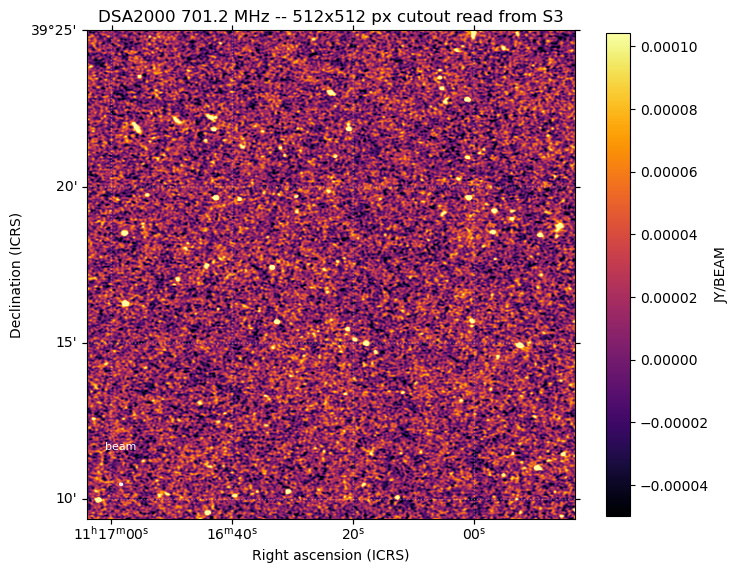

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

vmin, vmax = np.nanpercentile(cutout, [1, 99.5])
cut_wcs = wcs.celestial[y0:y1, x0:x1]

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(projection=cut_wcs)
im = ax.imshow(cutout, origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)

ax.set_xlabel("Right ascension (ICRS)")
ax.set_ylabel("Declination (ICRS)")
ax.set_title(f"{hdr['TELESCOP']} {hdr['CRVAL3'] / 1e6:.1f} MHz -- "
             f"{CUTOUT}x{CUTOUT} px cutout read from S3")
ax.grid(color="white", ls=":", alpha=0.3)
fig.colorbar(im, ax=ax, label=hdr["BUNIT"], shrink=0.85)

beam = Ellipse((0.07, 0.07), width=hdr["BMIN"] / abs(hdr["CDELT1"]) / CUTOUT,
               height=hdr["BMAJ"] / abs(hdr["CDELT1"]) / CUTOUT, angle=hdr["BPA"],
               transform=ax.transAxes, facecolor="white", edgecolor="white", alpha=0.9)
ax.add_patch(beam)
ax.text(0.07, 0.14, "beam", transform=ax.transAxes, color="white",
        ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 6. What a bigger read actually costs

A contiguous read is dominated by round-trip latency rather than by the number of bytes, so
asking for four times the area usually does not take four times as long. That is worth knowing
in both directions: do not agonise over trimming a cutout by a few pixels, but do not loop over
a thousand tiny reads either, because you pay the latency on every one.

The last row is the whole image, estimated rather than measured — reading it would pull the
full 2.2 GB and is exactly what this notebook is arguing against.

In [9]:
print(f"{'size':>12}  {'MiB':>8}  {'seconds':>8}")
per_mib = []
for n in (256, 512, 1024, 2048):
    h = n // 2
    t0 = time.perf_counter()
    block = hdu.section[0, 0, cy - h:cy + h, cx - h:cx + h]
    dt = time.perf_counter() - t0
    mib = block.nbytes / 1024**2
    per_mib.append(mib / dt)
    print(f"{n:>5} x {n:<4}  {mib:>8.1f}  {dt:>8.2f}")

full_mib = hdr["NAXIS1"] * hdr["NAXIS2"] * abs(hdr["BITPIX"]) / 8 / 1024**2
print(f"{'full image':>12}  {full_mib:>8.0f}  {full_mib / np.median(per_mib):>8.0f}  (estimated)")

        size       MiB   seconds


  256 x 256        0.5      0.57


  512 x 512        2.0      1.21


 1024 x 1024       8.0      2.47


 2048 x 2048      32.0      4.84
  full image      2265       928  (estimated)


## 7. Taking this elsewhere

Nothing above is specific to this bucket. `fits.open(..., use_fsspec=True)` works against any
S3 URL you have credentials for, and against public archives with `fsspec_kwargs={"anon": True}`
— MAST publishes HST, JWST and TESS at `s3://stpubdata` that way, with no account at all.

Worth carrying with you:

- **`.section`, not `.data`**, on anything remote. `.data` is the quiet two-gigabyte mistake.
- **Read headers first.** They are kilobytes. Decide what you want before fetching pixels.
- **Degenerate axes are normal in radio data.** Check `hdu.shape` before indexing, and use
  `wcs.celestial` for plotting.
- **Latency, not bandwidth, dominates.** Few large reads beat many small ones; parallelise with
  threads if you genuinely need many files.
- **Work near the data.** Running on this hub, in the bucket's region, is far quicker than
  pulling the same bytes to a laptop.
- **Close remote handles** when you are finished, or keep one open and reuse it — reopening
  re-fetches the headers and refills the cache.

In [10]:
hdul.close()
print("closed")

closed
